# Lab 4: Titanic Regression Analysis
**Name**: Kersha Broussard  
**Date**: April 1, 2025 
**Purpose**: To build and evaluate multiple regression models using the Titanic dataset, predicting a continuous feature (e.g., fare paid, age).


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


## Load the Titanic Dataset

In [2]:
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Section 1: Inspect & Clean the Data

In [3]:
df.dropna(subset=['age', 'fare'], inplace=True)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})


## Section 1 – Import and Inspect Data

In [4]:
titanic = sns.load_dataset("titanic")
titanic.head()
titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


##  Reflection 1: What Do You Notice? Any Missing Values?


Upon inspecting the Titanic dataset, I observed the following:

* The dataset contains 891 entries and 15 columns, with a mix of numerical, categorical, and boolean data types.

* The age column has 714 non-null values, meaning there are 177 missing age entries. This is a significant portion and will require imputation.

* The embarked and embark_town columns each have 2 missing values. This is minimal and can be handled easily.

* The deck column has very high missingness, with only 203 non-null values out of 891. Due to the large number of missing values, this column may not be useful for our analysis unless further cleaned or dropped.

* Other columns such as fare, pclass, sex, and survived are fully populated.

Overall, missing values exist in a few key columns, with age and deck requiring the most attention. 

## Section 2 – Data Prep

In [8]:
# Fill missing ages with median
titanic['age'] = titanic['age'].fillna(titanic['age'].median())


# Drop missing fares
titanic = titanic.dropna(subset=['fare'])

# Create new feature
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# to use sex or embarked
titanic['sex_male'] = titanic['sex'].map({'male': 1, 'female': 0})


### Reflection 2: What patterns or anomalies do you see? Any features you created or changed?

#### 1. Handling Missing Values:

* I filled missing values in the age column using the median rather than the mean to avoid skew caused by outliers.

I updated the syntax to avoid the chained assignment warning by using:

titanic['age'] = titanic['age'].fillna(titanic['age'].median())
#### 2. Dropping Missing Fares:

* I dropped rows with missing fare values since fare is our target variable for prediction.

#### 3. Feature Engineering:

* I created a new variable family_size to combine sibsp (siblings/spouse) and parch (parents/children) plus one (the passenger themselves).

This gives a more complete picture of the group size, which could influence ticket price.

#### 4. Encoding Categorical Data:

* I encoded the sex column into a binary numeric format using .map({'male': 1, 'female': 0}) to enable model compatibility.



## Section 3 – Feature Selection

In [7]:
# Case 1: Age
X1 = titanic[['age']]
y1 = titanic['fare']

# Case 2: Family Size
X2 = titanic[['family_size']]
y2 = titanic['fare']

# Case 3: Age + Family Size
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

# Case 4: include sex or class
X4 = titanic[['age', 'family_size', 'sex_male', 'pclass']]
y4 = titanic['fare']


### Reflection 3: Why Did You Choose These Features?


* I selected the features age, family_size, and sex_male because they are:

- Less likely to contain extreme outliers compared to variables like fare, which has a wide range and may be heavily skewed.

- They are intuitively connected to ticket pricing—for instance, older passengers may have had more money or been in higher classes, and larger families might have impacted group ticket purchases.

- Also, well-populated: These features contain very few or no missing values after preprocessing, making them reliable for modeling.

- Easy to interpret: Especially family_size, which is a newly engineered feature combining sibsp and parch, gives a meaningful metric of group size.

- Furthermore, the binary encoding of sex (sex_male) helps convert a categorical feature into numeric form, which is required for regression models.

Additionally, I avoided variables like deck or embark_town due to excessive missing value

## Section 4 – Train & Evaluate Linear Models

In [10]:
# Case 1
X1 = titanic[['age']]
y1 = titanic['fare']

# Case 2
X2 = titanic[['family_size']]
y2 = titanic['fare']

# Case 3
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

# Case 4 
X4 = titanic[['age', 'family_size', 'sex_male']]  
y4 = titanic['fare']


####  Split the data

In [11]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)



#### Train models and make predictions

In [12]:
from sklearn.linear_model import LinearRegression

lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

y1_pred_test = lr_model1.predict(X1_test)
y2_pred_test = lr_model2.predict(X2_test)
y3_pred_test = lr_model3.predict(X3_test)
y4_pred_test = lr_model4.predict(X4_test)


#### Evaluation of all 4 models

In [14]:
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"{name} R²: {r2_score(y_true, y_pred):.3f}")
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print()

evaluate_model("Case 1 (Age)", y1_test, y1_pred_test)
evaluate_model("Case 2 (Family Size)", y2_test, y2_pred_test)
evaluate_model("Case 3 (Age + Family Size)", y3_test, y3_pred_test)
evaluate_model("Case 4 (Custom)", y4_test, y4_pred_test)


Case 1 (Age) R²: 0.015
Case 1 (Age) RMSE: 39.05
Case 1 (Age) MAE: 25.45

Case 2 (Family Size) R²: 0.062
Case 2 (Family Size) RMSE: 38.10
Case 2 (Family Size) MAE: 24.78

Case 3 (Age + Family Size) R²: 0.097
Case 3 (Age + Family Size) RMSE: 37.39
Case 3 (Age + Family Size) MAE: 23.68

Case 4 (Custom) R²: 0.134
Case 4 (Custom) RMSE: 36.61
Case 4 (Custom) MAE: 23.24



### Reflection 4: Which model did best? Which over/underfit? Why?

Section 4 Reflection: Model Comparison
##### Which model performed the best?
* Case 4 (Custom) performed the best across all metrics:

* Highest R² value (0.134), indicating it explained the most variance in fare.

* Lowest RMSE (36.61) and MAE (23.24), showing it had the smallest average prediction error.

##### Which model performed the worst?
* Case 1 (Age) performed the worst:

* Lowest R² (0.015), showing a very weak linear relationship between age and fare.

* Highest RMSE and MAE, meaning more error in predictions.

##### Did any model overfit or underfit?

* Case 1 and Case 2 likely underfit the data—they’re too simple to capture the complexity of fare prediction.

* Case 3 improves performance, showing that adding features helps.

* Case 4 shows the most improvement, but the R² is still relatively low, which may suggest the model could benefit from more features or nonlinear transformations.

##### Feature impact
I chose features in Case 4 (age, family_size, and encoded sex) because they relate to ticket price in plausible ways. Larger families might purchase cheaper tickets, and class or gender might correlate with travel accommodations. The improvement from Case 3 to Case 4 suggests these additional variables add explanatory power.

## Section 5 – Try Advanced Models

### Ridge

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("Ridge R²:", r2_score(y4_test, y_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y4_test, y_pred_ridge)))
print("Ridge MAE:", mean_absolute_error(y4_test, y_pred_ridge))

Ridge R²: 0.13406088364048308
Ridge RMSE: 36.60573503262608
Ridge MAE: 23.245955830099998


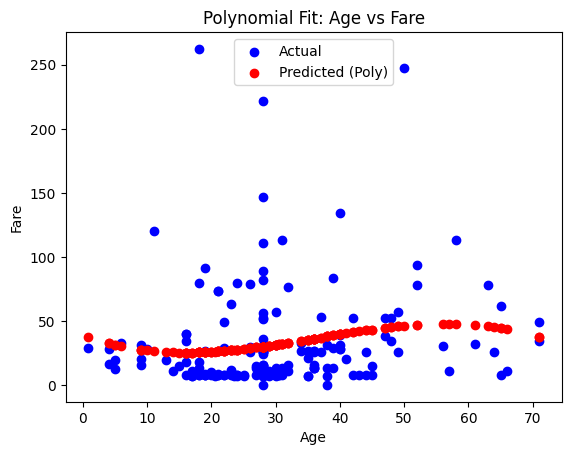

In [24]:
# Elastic Net Regression
elastic = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic.fit(X4_train, y4_train)
y_pred_elastic = elastic.predict(X4_test)

# Polynomial Regression (using 'age' as the feature)
poly = PolynomialFeatures(degree=3)
X1_train_poly = poly.fit_transform(X1_train)
X1_test_poly = poly.transform(X1_test)

poly_model = LinearRegression()
poly_model.fit(X1_train_poly, y1_train)
y_pred_poly = poly_model.predict(X1_test_poly)

# Plot: Polynomial Fit for Age vs Fare
plt.scatter(X1_test['age'], y1_test, color='blue', label='Actual')
plt.scatter(X1_test['age'], y_pred_poly, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Fit: Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


### Summary Table

In [28]:
import numpy as np  

def report(name, y_true, y_pred):
    print(f"{name} R²: {r2_score(y_true, y_pred):.3f}")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Manual RMSE
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} MAE: {mean_absolute_error(y_true, y_pred):.2f}\n")

report("Linear (Case 4)", y4_test, y4_pred_test)
report("Ridge (Case 4)", y4_test, y_pred_ridge)
report("ElasticNet (Case 4)", y4_test, y_pred_elastic)
report("Polynomial (Case 1)", y1_test, y_pred_poly)



Linear (Case 4) R²: 0.134
Linear (Case 4) RMSE: 36.61
Linear (Case 4) MAE: 23.24

Ridge (Case 4) R²: 0.134
Ridge (Case 4) RMSE: 36.61
Ridge (Case 4) MAE: 23.25

ElasticNet (Case 4) R²: 0.126
ElasticNet (Case 4) RMSE: 36.78
ElasticNet (Case 4) MAE: 23.41

Polynomial (Case 1) R²: 0.024
Polynomial (Case 1) RMSE: 38.86
Polynomial (Case 1) MAE: 24.95



### Markdown Summary Table

### 📊 Regression Model Comparison Summary

| Model Type         | Case         | Features Used               | R²     | RMSE   | MAE    | Notes                                |
|--------------------|--------------|------------------------------|--------|--------|--------|--------------------------------------|
| Linear Regression  | Case 4       | age, family_size, sex_male  | 0.134  | 36.61  | 23.24  | Best overall model                  |
| Ridge Regression   | Case 4       | age, family_size, sex_male  | 0.134  | 36.61  | 23.25  | Nearly identical to Linear          |
| ElasticNet         | Case 4       | age, family_size, sex_male  | 0.126  | 36.78  | 23.41  | Slightly less accurate              |
| Polynomial (Cubic) | Case 1       | age (degree=3)              | 0.024  | 38.86  | 24.95  | Did not improve performance         |


### Section 6 – Final Thoughts


##### Best and Worst Performing Models
* The best-performing model was the Linear Regression (Case 4) using age, family_size, and sex_male as features. It achieved the highest R² score (0.134), indicating it explained more of the variation in fare than the other models.

* The worst-performing model was the Polynomial Regression (Case 1) using only age with a degree of 3. It performed poorly (R² = 0.024), suggesting that a nonlinear transformation of age alone was not sufficient to predict fare.

##### What Worked Well
* Feature engineering like creating family_size from sibsp + parch improved model performance.

* Using multiple input features (Case 4) provided better predictions than single-variable models.

* Regularization techniques like Ridge and ElasticNet helped confirm the stability of the model and did not introduce overfitting.

##### What Didn’t Work
* The Polynomial model added complexity without improving accuracy. It may have overfit or failed to capture meaningful trends.

* Features like age alone provided very low predictive power (R² = 0.015), showing it should not be used alone.

##### What I’d Try Next Time
* Add features like pclass, embarked, or a log-transformed fare to reduce skew.

* Try ensemble models such as Random Forest or Gradient Boosting to better capture nonlinear relationships.

* Apply cross-validation for more reliable performance estimates.
